# Basmati Rice Sales Demand Dataset Exploration

This notebook explores the cleaned and weekly-aggregated Basmati Rice dataset for India.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('sales_demand.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,sku_id,unit_price,units_sold,cost_per_unit
0,2008-01-05,IND_BASMATI_001,33.739969,1146500.0,25.304977
1,2008-01-12,IND_BASMATI_001,34.908310,1615000.0,26.181232
2,2008-01-19,IND_BASMATI_001,31.132574,1569500.0,23.349431
3,2008-01-26,IND_BASMATI_001,29.249332,1594500.0,21.936999
4,2008-02-02,IND_BASMATI_001,39.085104,2827000.0,29.313828


## Summary Statistics

In [3]:
df.info()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           495 non-null    datetime64[ns]
 1   sku_id         495 non-null    object        
 2   unit_price     495 non-null    float64       
 3   units_sold     495 non-null    float64       
 4   cost_per_unit  495 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 19.5+ KB
                      date  unit_price    units_sold  cost_per_unit
count                  495  495.000000  4.950000e+02     495.000000
mean   2012-09-29 00:00:00   45.609117  2.191729e+06      34.206838
min    2008-01-05 00:00:00   17.999384  1.940000e+04      13.499538
25%    2010-05-18 12:00:00   33.855371  5.207500e+05      25.391528
50%    2012-09-29 00:00:00   43.192668  1.308800e+06      32.394501
75%    2015-02-10 12:00:00   54.215044  2.541600e+06      4

## Visualize Price and Volume Trends Over Time

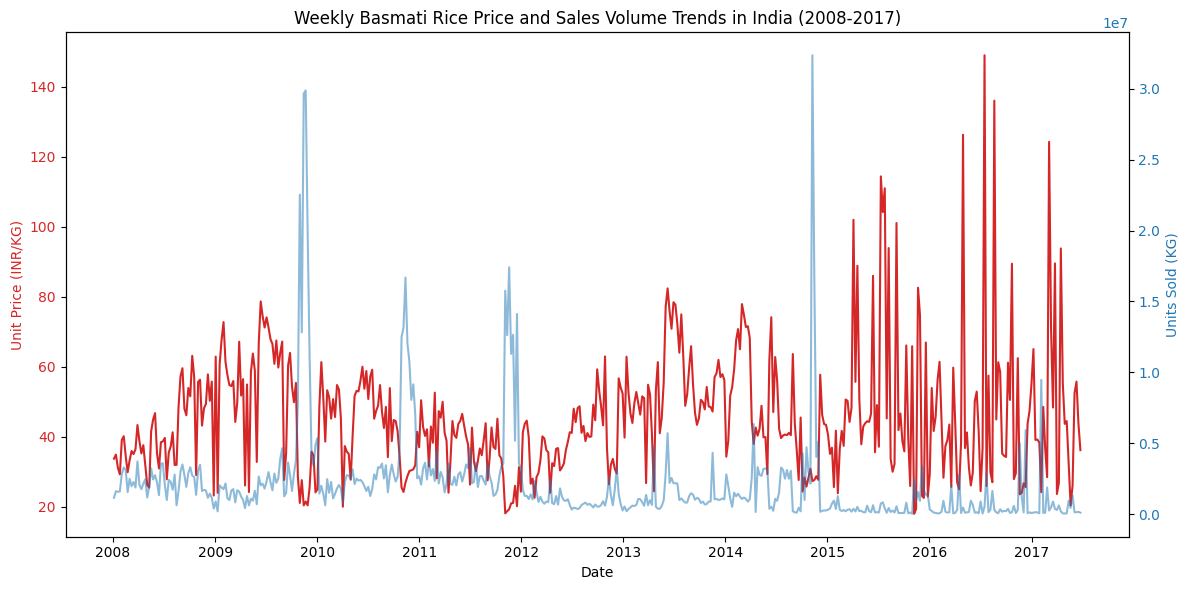

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Unit Price (INR/KG)', color=color)
ax1.plot(df['date'], df['unit_price'], color=color, label='Unit Price')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Units Sold (KG)', color=color)
ax2.plot(df['date'], df['units_sold'], color=color, alpha=0.5, label='Units Sold')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Weekly Basmati Rice Price and Sales Volume Trends in India (2008-2017)')
fig.tight_layout()
plt.show()

## Price Elasticity and Correlation

Correlation between Price and Units Sold: -0.2915


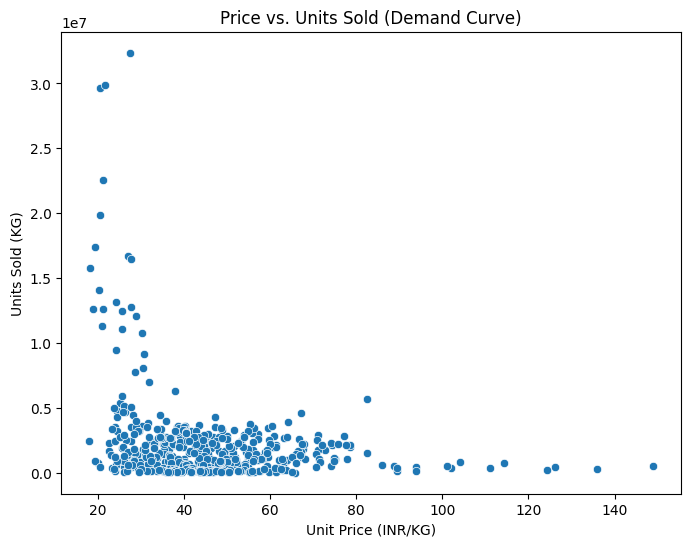

In [5]:
correlation = df['unit_price'].corr(df['units_sold'])
print(f'Correlation between Price and Units Sold: {correlation:.4f}')

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='unit_price', y='units_sold')
plt.title('Price vs. Units Sold (Demand Curve)')
plt.xlabel('Unit Price (INR/KG)')
plt.ylabel('Units Sold (KG)')
plt.show()